# Preparing the dataset for hippocampus segmentation

In this notebook I have used the skills and methods that we have talked about during our EDA Lesson to prepare the hippocampus dataset using Python. I followed the Notebook, writing snippets of code where directed so using Task comments, which expected me to put the proper imports in place. I wrote my code directly in the cell with TASK comment.


In [99]:
# I create a local virtual environment and install this notebook's dependencies.
from pathlib import Path
import subprocess
import sys

project_dir = Path.cwd()
venv_dir = project_dir / ".venv"
venv_python = venv_dir / "bin" / "python"

if not venv_python.exists():
    subprocess.run([sys.executable, "-m", "venv", str(venv_dir)], check=True)

subprocess.run(
    [str(venv_python), "-m", "pip", "install", "--upgrade", "pip", "nibabel", "matplotlib", "numpy"],
    check=True,
)

print(f"Environment ready: {venv_dir}")
print(f"To activate it in a terminal: source {venv_dir}/bin/activate")
print("Select the .venv kernel in Jupyter to run this notebook with this environment.")

Environment ready: /Users/elenaeyre/Desktop/Science/Courses/Udacity/AI_4_Healthcare/Course_2/Project_Lesson_6/.venv
To activate it in a terminal: source /Users/elenaeyre/Desktop/Science/Courses/Udacity/AI_4_Healthcare/Course_2/Project_Lesson_6/.venv/bin/activate
Select the .venv kernel in Jupyter to run this notebook with this environment.


In [1]:
# TASK: Import the following libraries that we will use: nibabel, matplotlib, numpy
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

Teachers considered convinient for my understanding of the data if I was able to use a tool that allows us to view NIFTI volumes, like [3D Slicer](https://www.slicer.org/). Thus, they referred to Slicer throughout the Notebook and pasted some images showing what my output might look like.

## Loading NIFTI images using NiBabel

NiBabel is a python library for working with neuro-imaging formats (including NIFTI) that we have used in some of the exercises throughout the course. Our volumes and labels are in NIFTI format, so we used nibabel to load and inspect them.

NiBabel documentation could be found here: https://nipy.org/nibabel/

Our dataset sits in two directories - *images* and *labels*. Each image is represented by a single file (we are fortunate to have our data converted to NIFTI) and has a corresponding label file which is named the same as the image file.

Our dataset could consider to be "dirty". There are a few images and labels that are not quite right. The dataset contains an equal amount of "correct" volumes and corresponding labels, and we don't need to alter values of any samples in order to get the clean dataset. 

In [2]:
# TASK: Your data sits in directory /data/TrainingSet.
# Load an image and a segmentation mask into variables called image and label.
from pathlib import Path
from shutil import move, rmtree
from urllib.request import urlretrieve
from zipfile import ZipFile

training_set_dir = Path("data/TrainingSet")
images_dir = training_set_dir / "images"
labels_dir = training_set_dir / "labels"

if not any(images_dir.glob("*.nii.gz")) or not any(labels_dir.glob("*.nii.gz")):
    if training_set_dir.exists():
        rmtree(training_set_dir)

    data_dir = training_set_dir.parent
    archive_path = data_dir / "starter-repo.zip"
    extracted_repo_dir = data_dir / "nd320-c3-3d-imaging-starter-master"
    data_dir.mkdir(parents=True, exist_ok=True)

    urlretrieve(
        "https://github.com/udacity/nd320-c3-3d-imaging-starter/archive/refs/heads/master.zip",
        archive_path,
    )
    with ZipFile(archive_path) as archive:
        archive.extractall(data_dir)
    move(str(extracted_repo_dir / "data/TrainingSet"), training_set_dir)
    archive_path.unlink()
    rmtree(extracted_repo_dir)

image_path = next(images_dir.glob("*.nii.gz"))
label_path = labels_dir / image_path.name
image = nib.load(image_path)
label = nib.load(label_path)

# get_fdata() converts NIFTI voxel data to NumPy arrays for inspection and visualization.
image_data = image.get_fdata()
label_data = label.get_fdata()

print(f"Image array: shape={image_data.shape}, dtype={image_data.dtype}")
print(f"Image intensity range: {image_data.min():.0f} to {image_data.max():.0f}")
print(f"Label array: shape={label_data.shape}, dtype={label_data.dtype}")
print(f"Label values: {np.unique(label_data).astype(int)}")

Image array: shape=(36, 57, 37), dtype=float64
Image intensity range: 0 to 1932
Label array: shape=(36, 57, 37), dtype=float64
Label values: [0 1 2]


Image dimensions (x, y, z): (36, 57, 37)
Label dimensions (x, y, z): (36, 57, 37)


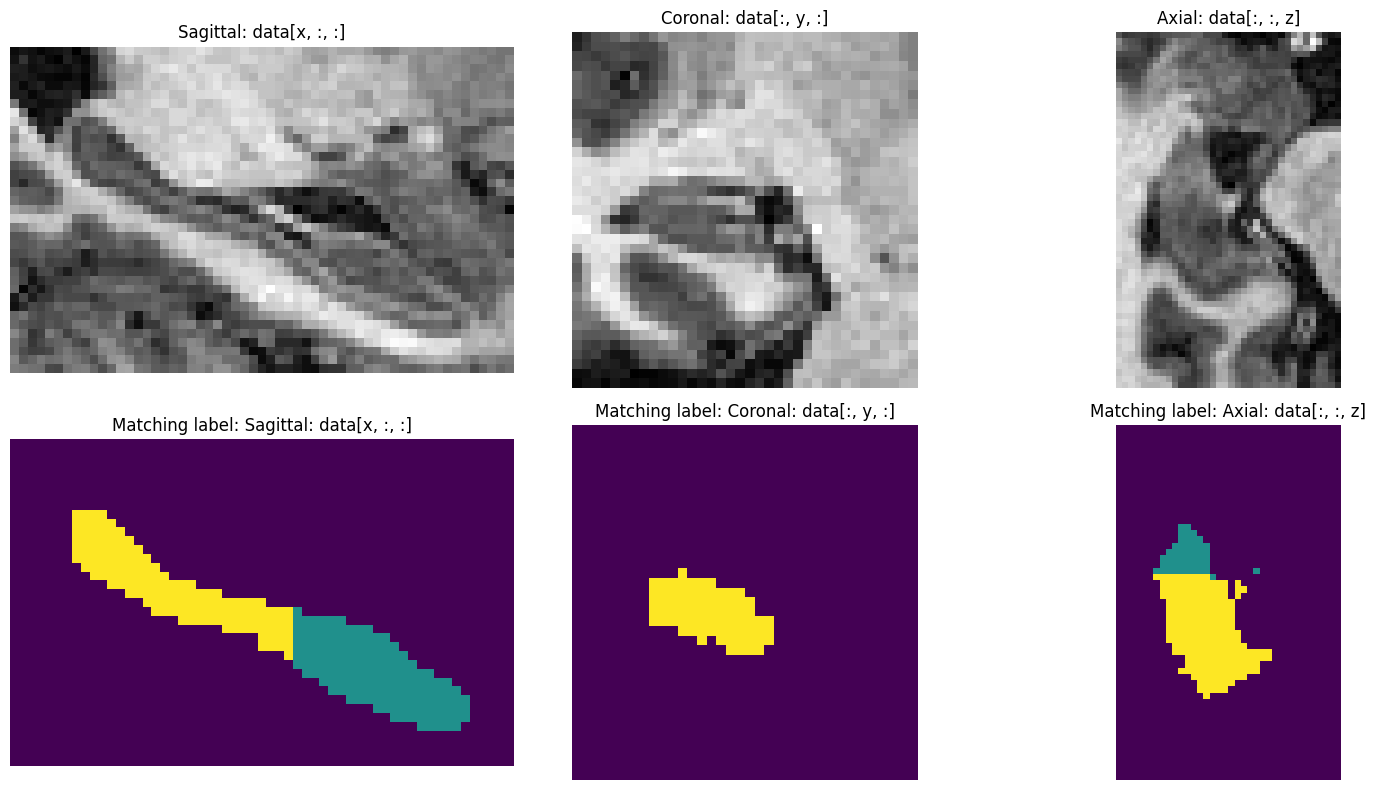

In [102]:
# NiBabel presents the NIFTI image and label as aligned 3D NumPy arrays.
# TASK: Visualize image and label slices to validate the data layout in each anatomical plane.
print(f"Image dimensions (x, y, z): {image_data.shape}")
print(f"Label dimensions (x, y, z): {label_data.shape}")

slice_views = [
    (image_data[image_data.shape[0] // 2, :, :], label_data[label_data.shape[0] // 2, :, :], "Sagittal: data[x, :, :]"),
    (image_data[:, image_data.shape[1] // 2, :], label_data[:, label_data.shape[1] // 2, :], "Coronal: data[:, y, :]"),
    (image_data[:, :, image_data.shape[2] // 2], label_data[:, :, label_data.shape[2] // 2], "Axial: data[:, :, z]"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for column, (image_slice, label_slice, title) in enumerate(slice_views):
    axes[0, column].imshow(image_slice.T, cmap="gray", origin="lower")
    axes[0, column].set_title(title)
    axes[0, column].axis("off")

    axes[1, column].imshow(label_slice.T, cmap="viridis", vmin=0, vmax=2, origin="lower")
    axes[1, column].set_title(f"Matching label: {title}")
    axes[1, column].axis("off")

plt.tight_layout()
plt.show()

I loaded volume into 3D Slicer to validate that my visualization was correct and checked for the shape of structures.

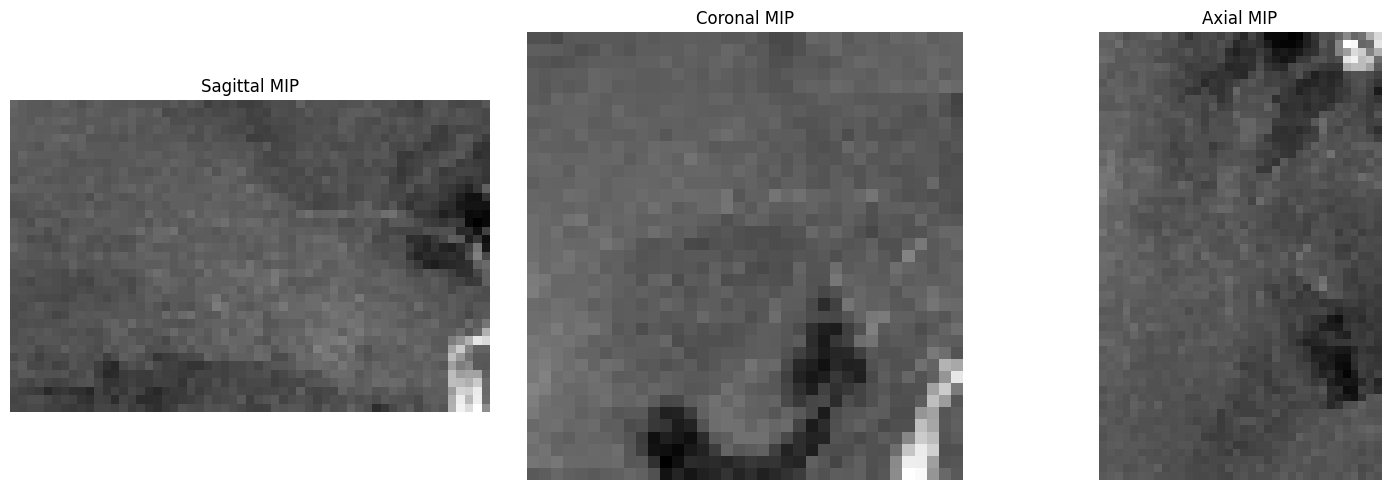

In [103]:
# Stand out suggestion: use one of the simple Volume Rendering algorithms that we've
# implemented in one of our earlier lessons to visualize some of these volumes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

projections = [
    (np.max(image_data, axis=0), "Sagittal MIP"),
    (np.max(image_data, axis=1), "Coronal MIP"),
    (np.max(image_data, axis=2), "Axial MIP"),
]

for axis, (projection, title) in zip(axes, projections):
    axis.imshow(projection.T, cmap="gray", origin="lower")
    axis.set_title(title)
    axis.axis("off")

plt.tight_layout()
plt.show()



## Looking at single image data

In this section I looked closer at the NIFTI representation of our volumes. In order to measure the physical volume of hippocampi, I needed to understand the relationship between the sizes of our voxels and the physical world.

In [104]:
# Nibabel supports many imaging formats, NIFTI being just one of them. I told you that our images 
# are in NIFTI, but you should confirm if this is indeed the format that we are dealing with
# TASK: using .header_class attribute - what is the format of our images?
print(image.header_class)

<class 'nibabel.nifti1.Nifti1Header'>


Further down I inspected .header attribute that provides access to NIFTI metadata. I used this resource as a reference for various fields: https://brainder.org/2012/09/23/the-nifti-file-format/

In [105]:
# TASK: How many bits per pixel are used?
bits_per_pixel = image.header["bitpix"]
print(f"Bits per pixel: {bits_per_pixel}")

Bits per pixel: 32


In [106]:
# TASK: What are the units of measurement?
spatial_unit, temporal_unit = image.header.get_xyzt_units()
print(f"Spatial unit: {spatial_unit}")
print(f"Temporal unit: {temporal_unit}")

Spatial unit: mm
Temporal unit: sec


In [107]:
# TASK: Do we have a regular grid? What are grid spacings?
voxel_spacing = image.header.get_zooms()[:3]
print(f"Voxel spacing (x, y, z): {voxel_spacing} mm")

Voxel spacing (x, y, z): (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm


In [108]:
# TASK: What dimensions represent axial, sagittal, and coronal slices? How do you know?
print(f"Axis codes: {nib.aff2axcodes(image.affine)}")
print("Sagittal slices: image_data[x, :, :]")
print("Coronal slices:  image_data[:, y, :]")
print("Axial slices:    image_data[:, :, z]")

Axis codes: ('R', 'A', 'S')
Sagittal slices: image_data[x, :, :]
Coronal slices:  image_data[:, y, :]
Axial slices:    image_data[:, :, z]


In [109]:
# By now you should have enough information to decide the physical dimensions of a voxel.
# TASK: Compute the physical volume (in mm^3) of the hippocampus using the loaded label.
spatial_unit, _ = label.header.get_xyzt_units()
voxel_spacing = label.header.get_zooms()[:3]
voxel_volume_mm3 = np.prod(voxel_spacing)

anterior_voxels = np.count_nonzero(label_data == 1)
posterior_voxels = np.count_nonzero(label_data == 2)
hippocampus_voxels = anterior_voxels + posterior_voxels

anterior_volume_mm3 = anterior_voxels * voxel_volume_mm3
posterior_volume_mm3 = posterior_voxels * voxel_volume_mm3
hippocampus_volume_mm3 = hippocampus_voxels * voxel_volume_mm3

print(f"Spatial unit: {spatial_unit}")
print(f"Voxel spacing (x, y, z): {voxel_spacing} {spatial_unit}")
print(f"Single-voxel volume: {voxel_volume_mm3:.3f} {spatial_unit}^3")
print(f"Anterior hippocampus: {anterior_voxels} voxels = {anterior_volume_mm3:.2f} {spatial_unit}^3")
print(f"Posterior hippocampus: {posterior_voxels} voxels = {posterior_volume_mm3:.2f} {spatial_unit}^3")
print(f"Total hippocampus: {hippocampus_voxels} voxels = {hippocampus_volume_mm3:.2f} {spatial_unit}^3")

Spatial unit: mm
Voxel spacing (x, y, z): (np.float32(1.0), np.float32(1.0), np.float32(1.0)) mm
Single-voxel volume: 1.000 mm^3
Anterior hippocampus: 2212 voxels = 2212.00 mm^3
Posterior hippocampus: 1939 voxels = 1939.00 mm^3
Total hippocampus: 4151 voxels = 4151.00 mm^3


## Plotting some charts

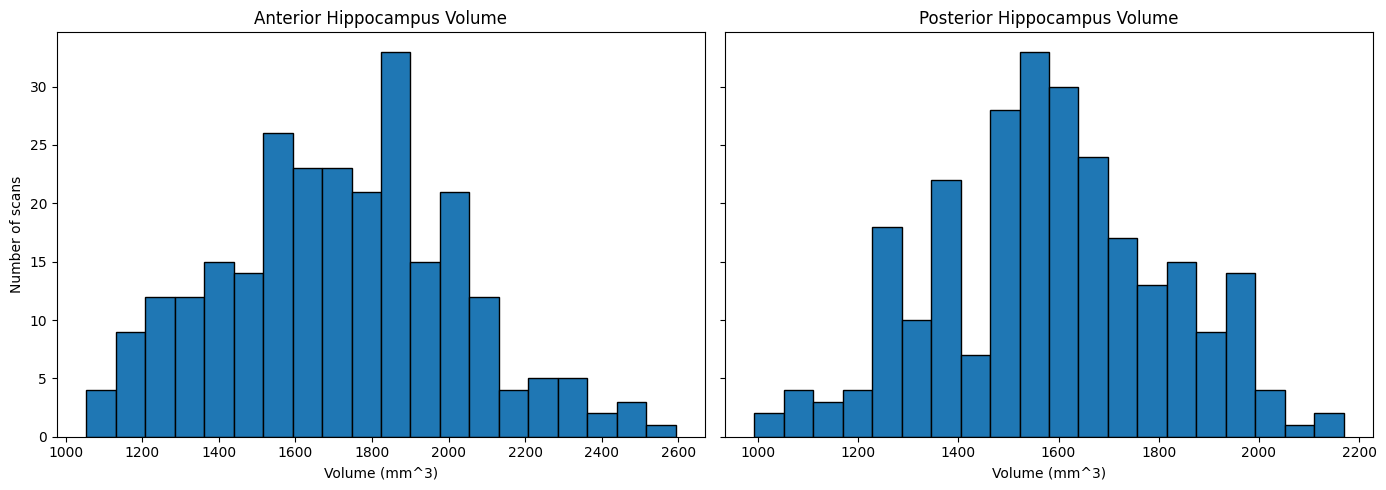

Anterior volume range: 1054.00 to 2593.00 mm^3
Posterior volume range: 993.00 to 2169.00 mm^3


In [3]:
# TASK: Plot histograms of hippocampus volumes in the dataset and compare them with the population chart.
# Volumes are recomputed from the cleaned labels only, so the outlier excluded during data cleaning is not included.
anterior_volumes_mm3 = []
posterior_volumes_mm3 = []

for label_file in sorted((training_set_dir / "labels").glob("*.nii.gz")):
    image_file = training_set_dir / "images" / label_file.name
    if not image_file.exists():
        continue

    current_image = nib.load(image_file)
    current_label = nib.load(label_file)
    current_label_data = current_label.get_fdata()
    voxel_volume_mm3 = np.prod(current_label.header.get_zooms()[:3])
    hippocampus_volume_mm3 = np.count_nonzero(current_label_data > 0) * voxel_volume_mm3

    if current_image.shape != current_label.shape:
        continue
    if not set(np.unique(current_label_data)).issubset({0, 1, 2}):
        continue
    if not 2200 <= hippocampus_volume_mm3 <= 4500:
        continue

    anterior_volumes_mm3.append(
        np.count_nonzero(current_label_data == 1) * voxel_volume_mm3
    )
    posterior_volumes_mm3.append(
        np.count_nonzero(current_label_data == 2) * voxel_volume_mm3
    )

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
axes[0].hist(anterior_volumes_mm3, bins=20, edgecolor="black")
axes[0].set_title("Anterior Hippocampus Volume")
axes[0].set_xlabel("Volume (mm^3)")
axes[0].set_ylabel("Number of scans")

axes[1].hist(posterior_volumes_mm3, bins=20, edgecolor="black")
axes[1].set_title("Posterior Hippocampus Volume")
axes[1].set_xlabel("Volume (mm^3)")

plt.tight_layout()
plt.show()

print(f"Anterior volume range: {min(anterior_volumes_mm3):.2f} to {max(anterior_volumes_mm3):.2f} mm^3")
print(f"Posterior volume range: {min(posterior_volumes_mm3):.2f} to {max(posterior_volumes_mm3):.2f} mm^3")


In [111]:
# TASK: Copy the clean dataset to the output folder inside section1/out. You will use it in the next Section
from shutil import copy2, rmtree

output_dir = Path("section1/out")
output_images_dir = output_dir / "images"
output_labels_dir = output_dir / "labels"

if output_dir.exists():
    rmtree(output_dir)
output_images_dir.mkdir(parents=True)
output_labels_dir.mkdir()

clean_files = []
excluded_files = {}

for source_image_path in sorted((training_set_dir / "images").glob("*.nii.gz")):
    source_label_path = training_set_dir / "labels" / source_image_path.name

    if not source_label_path.exists():
        excluded_files[source_image_path.name] = "missing matching label"
        continue

    source_image = nib.load(source_image_path)
    source_label = nib.load(source_label_path)
    source_label_data = source_label.get_fdata()
    voxel_volume_mm3 = np.prod(source_label.header.get_zooms()[:3])
    hippocampus_volume_mm3 = np.count_nonzero(source_label_data > 0) * voxel_volume_mm3

    if source_image.shape != source_label.shape:
        excluded_files[source_image_path.name] = "image and label shapes do not match"
    elif not set(np.unique(source_label_data)).issubset({0, 1, 2}):
        excluded_files[source_image_path.name] = "unexpected label values"
    elif not 2200 <= hippocampus_volume_mm3 <= 4500:
        excluded_files[source_image_path.name] = "hippocampus volume outside expected range"
    else:
        copy2(source_image_path, output_images_dir / source_image_path.name)
        copy2(source_label_path, output_labels_dir / source_label_path.name)
        clean_files.append(source_image_path.name)

print(f"Copied {len(clean_files)} clean image-label pairs to {output_dir}")
print("Excluded files:")
for filename, reason in excluded_files.items():
    print(f"- {filename}: {reason}")

Copied 260 clean image-label pairs to section1/out
Excluded files:
- hippocampus_010.nii.gz: image and label shapes do not match
- hippocampus_118.nii.gz: missing matching label
- hippocampus_281.nii.gz: image and label shapes do not match


## Final remarks

In this section I have inspected a dataset of MRI scans and related segmentations, represented as NIFTI files. I have visualized some slices, and understood the layout of the data. I have inspected file headers to understand what how the image dimensions relate to the physical world and I have understood how to measure our volume. I have then inspected dataset for outliers, and have created a clean set that is ready for consumption by my ML algorithm. 